# Pole shape — data sanity check

Run this notebook from the **repository root** (so `data/images` resolves). In VS Code/Cursor: open the folder `pole-shape-classifer`, then run cells. Select the project interpreter: `.venv/bin/python`.

In [1]:
%matplotlib inline

from pathlib import Path

import keras
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from keras import layers
from keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

ROOT = Path.cwd()
IMAGE_DIR = ROOT / "data" / "images"
if not IMAGE_DIR.is_dir():
    raise FileNotFoundError(
        f"Missing {IMAGE_DIR}. cd to the repo root or fix IMAGE_DIR."
    )

In [2]:
# Split the data into train, val and test
batch_size = 32
seed = 1337
# Load 80% of the data for training
full_ds = keras.utils.image_dataset_from_directory(
    IMAGE_DIR,
    seed=seed,
    shuffle=True,
    image_size=(224, 224),
    batch_size=None
)

# Split into 80% train and 20% temp
train_ds, temp_ds = tf.keras.utils.split_dataset(full_ds, left_size=0.8, shuffle=True, seed=seed)

# Split the 20% temp into 10% val and 10% test (half of the remainder)
val_ds, test_ds = tf.keras.utils.split_dataset(temp_ds, left_size=0.5, shuffle=True, seed=seed)

# Batch AFTER splitting
train_ds = train_ds.batch(batch_size)
val_ds   = val_ds.batch(batch_size)
test_ds  = test_ds.batch(batch_size)


Found 214 files belonging to 2 classes.


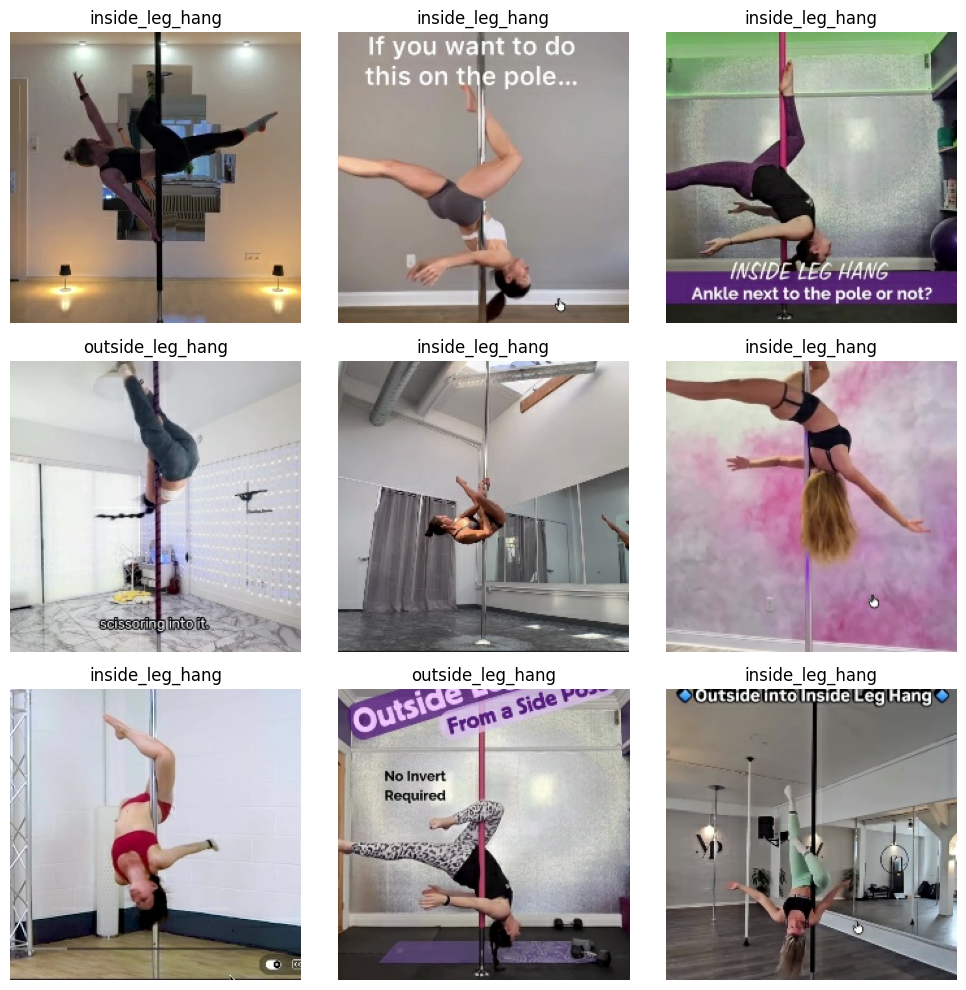

In [3]:
class_names = full_ds.class_names
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    n = min(9, int(images.shape[0]))
    for i in range(n):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        lbl = int(labels[i])
        title = class_names[lbl] if lbl < len(class_names) else str(lbl)
        plt.title(title)
        plt.axis("off")
plt.tight_layout()
plt.show()

# Train baseline model - EfficientNetB0

In [4]:
# 1. Load the base model with pre-trained ImageNet weights
# include_top=False removes the final 1000-class layer
# trainable = False freezes the base model (don't train its internal weights yet)
efficient_base = EfficientNetB0(weights='imagenet', 
include_top=False)
efficient_base.trainable = True
# 2. Add custom layers for your specific task (e.g., 2 classes: inside leg hang v.s. outside leg hang)
inputs = keras.Input(shape=(224, 224, 3))
x = efficient_base(inputs)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.25)(x)  # Higher dropout rate to prevent overfitting
outputs = Dense(2, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs)

# 4. Compile
model.compile(optimizer= "adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])



In [5]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 4,010,110 (15.30 MB)

 Non-trainable params: 42,023 (164.16 KB)

Basic model overfits since dataset is too small.

In [6]:
# Callbacks are passed to the model via the callbacks argument in
# fit(), which takes a list of callbacks. You can pass any number of
# callbacks.
callbacks_list = [
    # Interrupts training when improvement stops
    keras.callbacks.EarlyStopping(
        # Monitors the model's validation accuracy
        monitor="accuracy",
        # Interrupts training when accuracy has stopped improving for
        # more than one epoch (that is, two epochs)
        patience=1,
    ),
    # Saves the current weights after every epoch
    keras.callbacks.ModelCheckpoint(
        # Path to the destination model file
        filepath="checkpoint_path.keras",
        # These two arguments mean you won't overwrite the model file
        # unless val_loss has improved, which allows you to keep the
        # best model seen during training.
        monitor="val_loss",
        save_best_only=True,
    ),
]


# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    callbacks=callbacks_list,
    epochs=10  # Start with 10 for transfer learning
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7602 - loss: 0.4763 - val_accuracy: 0.8636 - val_loss: 0.2945
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 927ms/step - accuracy: 0.9942 - loss: 0.0456 - val_accuracy: 0.9545 - val_loss: 0.1590
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 884ms/step - accuracy: 1.0000 - loss: 0.0184 - val_accuracy: 0.9545 - val_loss: 0.2419
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 900ms/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 0.9545 - val_loss: 0.2282


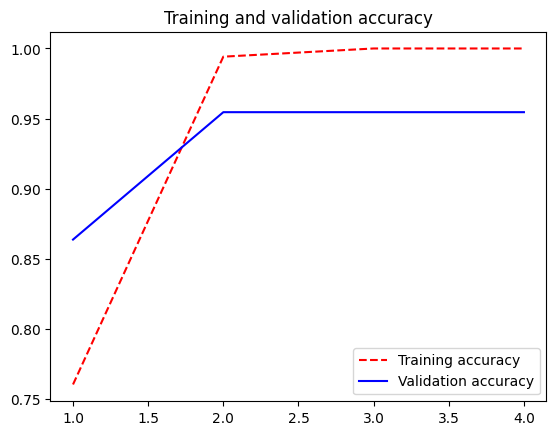

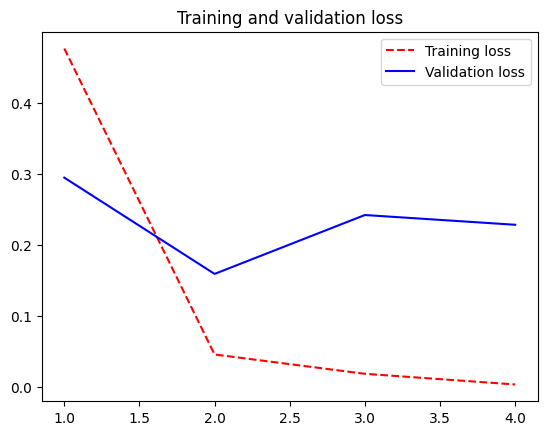

In [7]:

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [9]:
# save model
model.save("efficientnetb0_v1.keras")

# Fine Tune EfficientNet

In [25]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# unfreese top layers of efficientnet
base_model.trainable = True

# 3. Add custom layers for your specific task (e.g., 2 classes: Inside v.s. Outside leg hang)
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.25)(x)  # Higher dropout rate to prevent overfitting
output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # smaller than before
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)